# Query Execution Models: Iterator vs Vectorized vs JIT

**Data Mastery Lab** — Salesforce Data Cloud

---

## What we'll explore

1. **Iterator (Volcano) model** — the classical pull-based, tuple-at-a-time approach
2. **Vectorized execution** — batch-at-a-time processing with SIMD and cache locality
3. **JIT compilation** — generating native code for each query, eliminating interpretation
4. **Head-to-head benchmarks** — measuring the real difference on modern hardware

### The core insight

> The three models differ in **how much work happens per function call**
> and **how well they use modern CPU hardware** (caches, pipelines, SIMD).

| Model | Unit of work | Function calls | CPU utilization |
|-------|-------------|----------------|------------------|
| **Iterator** | 1 tuple | N × operators | Poor (cache misses, branch mispredicts) |
| **Vectorized** | ~1024 tuples | N/1024 × operators | Good (SIMD, cache-friendly loops) |
| **JIT compiled** | Full pipeline | 1 fused loop | Best (no interpretation, compiler-optimized) |

### Key references

- **Goetz Graefe, 1994** — "Volcano: An Extensible and Parallel Query Evaluation System"
- **Marcin Zukowski (CWI), 2005** — MonetDB/X100: the paper that introduced vectorized execution
- **Thomas Neumann (TU Munich), 2011** — "Efficiently Compiling Efficient Query Plans for Modern Hardware" (HyPer/Umbra)
- **CMU 15-721 (Andy Pavlo)** — Lectures on execution models, vectorization, and compilation

In [1]:
import sys, os, shutil, time, random
sys.path.insert(0, '.')
from query_viz import (render_volcano_model, render_vectorized_model,
                       render_jit_model, render_three_models_comparison,
                       render_cache_behavior)
from IPython.display import display, Image
import matplotlib.pyplot as plt
import numpy as np

OUTPUT_DIR = "_output"
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)
os.makedirs(OUTPUT_DIR)
print(f"Output directory: {OUTPUT_DIR}/")

Output directory: _output/


---
## Part 1: The Iterator (Volcano) Model

Invented by Goetz Graefe (1990s). Used by PostgreSQL, MySQL, SQLite, and most traditional databases.

Every operator in the query plan implements a `next()` method:
- `next()` returns **one tuple** at a time
- Each operator **pulls** from its child by calling `child.next()`
- The root operator drives everything by repeatedly calling `next()`

```
Aggregate.next()  →  calls Filter.next()  →  calls Scan.next()
     ↑                      ↑                      ↑
   1 tuple              1 tuple               1 tuple from disk
```

**Elegant and composable.** Any operator can be plugged in anywhere.
But there's a hidden cost: **virtual function dispatch per tuple, per operator**.

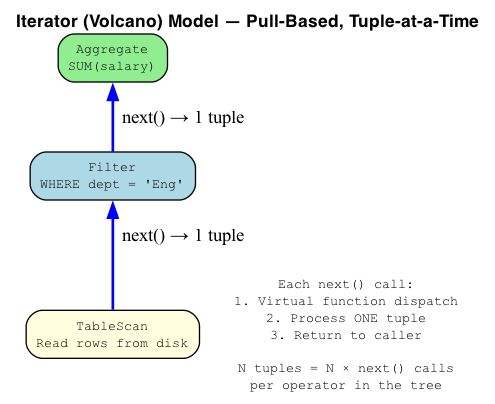

In [2]:
# Visualize the Volcano model
path = render_volcano_model(
    operators=[
        {"name": "TableScan", "description": "Read rows from disk", "color": "lightyellow"},
        {"name": "Filter", "description": "WHERE dept = 'Eng'", "color": "lightblue"},
        {"name": "Aggregate", "description": "SUM(salary)", "color": "lightgreen"},
    ],
    filename="volcano", output_dir=OUTPUT_DIR,
)
if path.endswith(".png"):
    display(Image(filename=path))

In [3]:
# Implement the iterator model in Python

class ScanOperator:
    """Reads from an in-memory table, one row at a time."""
    def __init__(self, data: dict):
        self.data = data
        self.n_rows = len(next(iter(data.values())))
        self.pos = 0
        self.calls = 0
    
    def next(self):
        self.calls += 1
        if self.pos >= self.n_rows:
            return None
        row = {col: self.data[col][self.pos] for col in self.data}
        self.pos += 1
        return row

class FilterOperator:
    """Filters rows based on a predicate."""
    def __init__(self, child, column: str, value):
        self.child = child
        self.column = column
        self.value = value
        self.calls = 0
    
    def next(self):
        self.calls += 1
        while True:
            row = self.child.next()
            if row is None:
                return None
            if row[self.column] == self.value:
                return row

class AggregateOperator:
    """Computes SUM of a column."""
    def __init__(self, child, column: str):
        self.child = child
        self.column = column
        self.calls = 0
    
    def next(self):
        self.calls += 1
        total = 0
        count = 0
        while True:
            row = self.child.next()
            if row is None:
                return {"sum": total, "count": count} if count > 0 else None
            total += row[self.column]
            count += 1

# Generate test data
N = 1_000_000
random.seed(42)
departments = ["Engineering", "Sales", "Marketing", "Finance", "HR"]
data = {
    "id": list(range(N)),
    "department": [random.choice(departments) for _ in range(N)],
    "salary": [random.randint(50000, 200000) for _ in range(N)],
}

# Query: SELECT SUM(salary) FROM employees WHERE department = 'Engineering'
print("Query: SELECT SUM(salary) WHERE department = 'Engineering'")
print(f"Data: {N:,} rows\n")

scan = ScanOperator(data)
filt = FilterOperator(scan, "department", "Engineering")
agg = AggregateOperator(filt, "salary")

start = time.time()
result = agg.next()
iterator_time = time.time() - start

print(f"Result: SUM={result['sum']:,}, COUNT={result['count']:,}")
print(f"Time: {iterator_time:.3f}s")
print(f"\nFunction calls:")
print(f"  Scan.next():      {scan.calls:>10,}")
print(f"  Filter.next():    {filt.calls:>10,}")
print(f"  Aggregate.next(): {agg.calls:>10,}")
print(f"  Total:            {scan.calls + filt.calls + agg.calls:>10,}")
print(f"\n→ {scan.calls + filt.calls + agg.calls:,} function calls for {N:,} rows.")
print(f"→ Each call has: virtual dispatch + function prologue/epilogue + potential cache miss.")
print(f"→ The actual computation (compare + add) is trivial. The overhead dominates.")

Query: SELECT SUM(salary) WHERE department = 'Engineering'
Data: 1,000,000 rows



Result: SUM=25,027,727,296, COUNT=200,387
Time: 0.255s

Function calls:
  Scan.next():       1,000,001
  Filter.next():       200,388
  Aggregate.next():          1
  Total:             1,200,390

→ 1,200,390 function calls for 1,000,000 rows.
→ Each call has: virtual dispatch + function prologue/epilogue + potential cache miss.
→ The actual computation (compare + add) is trivial. The overhead dominates.


---
## Part 2: Vectorized Execution

Introduced by the MonetDB/X100 paper (Zukowski et al., CWI Amsterdam, 2005).
Used by DuckDB, Snowflake, Velox (Meta), DataFusion, ClickHouse.

Same pull-based `next()` interface, but returns a **batch** (vector) of tuples:
- Typically 1024 or 2048 values per batch
- Each operator processes the entire batch in a **tight loop**
- Tight loops enable: **SIMD instructions**, **CPU prefetching**, **branch prediction**

The key insight: amortize the function call overhead across 1024 tuples.

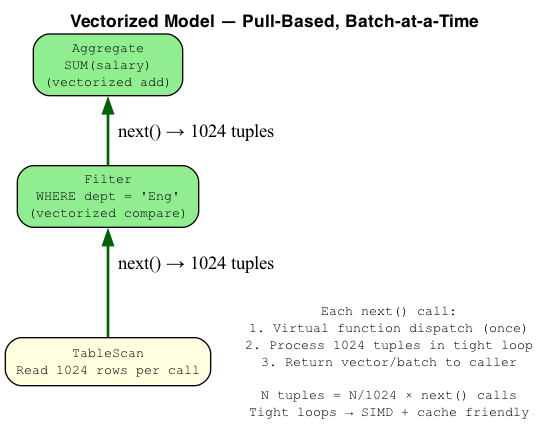

In [4]:
path = render_vectorized_model(
    operators=[
        {"name": "TableScan", "description": "Read 1024 rows per call", "color": "lightyellow"},
        {"name": "Filter", "description": "WHERE dept = 'Eng'\n(vectorized compare)", "color": "lightgreen"},
        {"name": "Aggregate", "description": "SUM(salary)\n(vectorized add)", "color": "lightgreen"},
    ],
    batch_size=1024,
    filename="vectorized", output_dir=OUTPUT_DIR,
)
if path.endswith(".png"):
    display(Image(filename=path))

In [5]:
# Implement vectorized execution

BATCH_SIZE = 1024

class VecScan:
    def __init__(self, data: dict):
        self.data = data
        self.n_rows = len(next(iter(data.values())))
        self.pos = 0
        self.calls = 0
    
    def next_batch(self):
        self.calls += 1
        if self.pos >= self.n_rows:
            return None
        end = min(self.pos + BATCH_SIZE, self.n_rows)
        batch = {col: self.data[col][self.pos:end] for col in self.data}
        self.pos = end
        return batch

class VecFilter:
    def __init__(self, child, column: str, value):
        self.child = child
        self.column = column
        self.value = value
        self.calls = 0
    
    def next_batch(self):
        self.calls += 1
        batch = self.child.next_batch()
        if batch is None:
            return None
        # Vectorized filter: tight loop over entire batch
        mask = [batch[self.column][i] == self.value for i in range(len(batch[self.column]))]
        return {col: [batch[col][i] for i, m in enumerate(mask) if m] for col in batch}

class VecAggregate:
    def __init__(self, child, column: str):
        self.child = child
        self.column = column
        self.calls = 0
    
    def next_batch(self):
        self.calls += 1
        total = 0
        count = 0
        while True:
            batch = self.child.next_batch()
            if batch is None:
                return {"sum": total, "count": count} if count > 0 else None
            total += sum(batch[self.column])  # vectorized sum over batch
            count += len(batch[self.column])

# Run the same query
scan = VecScan(data)
filt = VecFilter(scan, "department", "Engineering")
agg = VecAggregate(filt, "salary")

start = time.time()
result = agg.next_batch()
vec_time = time.time() - start

print(f"Result: SUM={result['sum']:,}, COUNT={result['count']:,}")
print(f"Time: {vec_time:.3f}s (vs iterator: {iterator_time:.3f}s) → {iterator_time/vec_time:.1f}x faster")
print(f"\nFunction calls:")
print(f"  Scan.next_batch():      {scan.calls:>8,}  (vs {N:,} for iterator)")
print(f"  Filter.next_batch():    {filt.calls:>8,}")
print(f"  Aggregate.next_batch(): {agg.calls:>8,}")
total_calls = scan.calls + filt.calls + agg.calls
print(f"  Total:                  {total_calls:>8,}")
print(f"\n→ {total_calls:,} function calls vs {N + N + 1:,} for iterator.")
print(f"→ {(N + N + 1) // total_calls}x fewer function calls.")
print(f"→ Each call processes {BATCH_SIZE} tuples in a tight loop — much better for CPU.")

Result: SUM=25,027,727,296, COUNT=200,387
Time: 0.115s (vs iterator: 0.255s) → 2.2x faster

Function calls:
  Scan.next_batch():           978  (vs 1,000,000 for iterator)
  Filter.next_batch():         978
  Aggregate.next_batch():        1
  Total:                     1,957

→ 1,957 function calls vs 2,000,001 for iterator.
→ 1021x fewer function calls.
→ Each call processes 1024 tuples in a tight loop — much better for CPU.


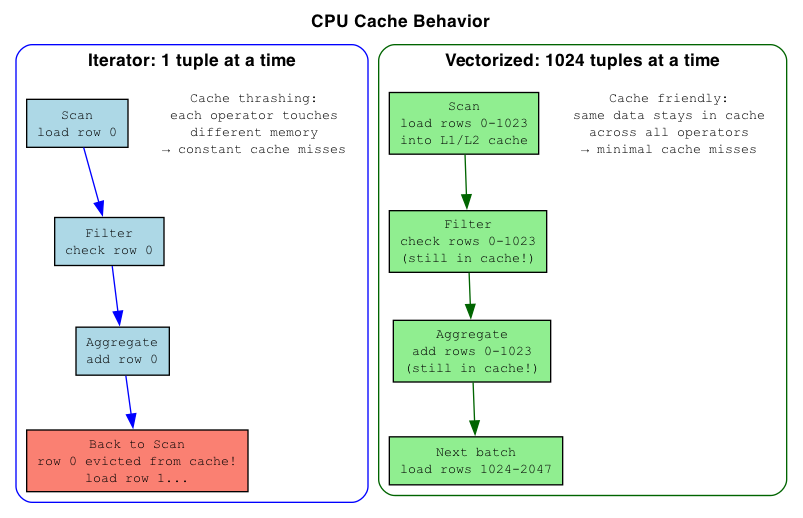

Why vectorized is faster — it's not just fewer function calls:

1. CACHE LOCALITY: a batch of 1024 ints = 8KB. Fits in L1 cache (32-64KB).
   All three operators process the SAME 8KB before moving on.
   Iterator: each operator touches different memory → constant cache misses.

2. SIMD: a tight loop over 1024 ints can use AVX2/AVX-512 instructions.
   Process 8-16 integers per CPU cycle instead of 1.
   Iterator: 1 tuple per call → SIMD impossible.

3. BRANCH PREDICTION: tight loop = predictable branch pattern.
   CPU pipeline stays full. Iterator: unpredictable virtual dispatch.


In [6]:
# Show CPU cache behavior difference
path = render_cache_behavior(filename="cache", output_dir=OUTPUT_DIR)
if path.endswith(".png"):
    display(Image(filename=path))

print("Why vectorized is faster — it's not just fewer function calls:")
print()
print("1. CACHE LOCALITY: a batch of 1024 ints = 8KB. Fits in L1 cache (32-64KB).")
print("   All three operators process the SAME 8KB before moving on.")
print("   Iterator: each operator touches different memory → constant cache misses.")
print()
print("2. SIMD: a tight loop over 1024 ints can use AVX2/AVX-512 instructions.")
print("   Process 8-16 integers per CPU cycle instead of 1.")
print("   Iterator: 1 tuple per call → SIMD impossible.")
print()
print("3. BRANCH PREDICTION: tight loop = predictable branch pattern.")
print("   CPU pipeline stays full. Iterator: unpredictable virtual dispatch.")

In [7]:
# What does REAL vectorized execution look like? NumPy.
# NumPy processes arrays in tight C loops with SIMD — this is exactly what
# DuckDB, Velox, and Snowflake do internally.

# Our Python "vectorized" above showed the CONCEPT (batching reduces function calls),
# but Python can't actually use SIMD. NumPy can.

salary_list = data["salary"]
dept_list = data["department"]

# Pure Python loop (what iterator execution looks like at the CPU level)
start = time.time()
total = 0
for i in range(N):
    if dept_list[i] == "Engineering":
        total += salary_list[i]
python_time = time.time() - start

# NumPy = real vectorized execution (tight C loops + SIMD)
salary_arr = np.array(data["salary"])
dept_arr = np.array(data["department"])

start = time.time()
mask = dept_arr == "Engineering"          # vectorized compare: SIMD
np_total = salary_arr[mask].sum()         # vectorized sum: SIMD
numpy_time = time.time() - start

print(f"SUM(salary) WHERE dept='Engineering' on {N:,} rows:\n")
print(f"  Python loop (iterator-like):       {python_time:.3f}s")
print(f"  NumPy (real vectorized execution):  {numpy_time:.3f}s")
print(f"  Speedup:                            {python_time/numpy_time:.0f}x")
print(f"\n→ NumPy IS vectorized execution. It's not a separate model.")
print(f"→ 'Vectorized' means: process arrays in tight loops that use SIMD instructions.")
print(f"→ Our Python batching above showed the batching concept (fewer function calls),")
print(f"  but real vectorized engines like DuckDB write those inner loops in C/C++")
print(f"  where the compiler auto-vectorizes them to AVX2/AVX-512 SIMD instructions.")
print(f"→ That's the {python_time/numpy_time:.0f}x difference.")

SUM(salary) WHERE dept='Engineering' on 1,000,000 rows:

  Python loop (iterator-like):       0.057s
  NumPy (real vectorized execution):  0.005s
  Speedup:                            11x

→ NumPy IS vectorized execution. It's not a separate model.
→ 'Vectorized' means: process arrays in tight loops that use SIMD instructions.
→ Our Python batching above showed the batching concept (fewer function calls),
  but real vectorized engines like DuckDB write those inner loops in C/C++
  where the compiler auto-vectorizes them to AVX2/AVX-512 SIMD instructions.
→ That's the 11x difference.


### Why vectorized execution and columnar storage are a perfect pair

Vectorized execution doesn't just improve CPU utilization — it **compounds** with columnar storage
to create a multiplicative effect across the entire stack:

```
DISK (Parquet)          MEMORY                  CPU (SIMD)
┌─────────────┐    ┌─────────────┐    ┌───────────────────────┐
│ salary col: │    │ salary[]:   │    │ SIMD register:        │
│ [150K,120K, │──→ │ [150K,120K, │──→ │ [150K|120K|160K|110K] │
│  160K,110K, │    │  160K,110K, │    │ + filter mask         │
│  155K, ...] │    │  155K, ...] │    │ = 4 values per cycle  │
└─────────────┘    └─────────────┘    └───────────────────────┘
  contiguous          contiguous          contiguous → SIMD
  on disk             in RAM              in register
```

**The three layers reinforce each other:**

1. **Columnar on disk** (Parquet): salary values are stored contiguously. A scan reads
   only the salary column — sequential I/O, no wasted bytes on other columns.

2. **Columnar in memory**: the column lands in RAM as a dense array. No per-row object headers,
   no pointer chasing, no mixed types. Just a flat `int64[]`.

3. **SIMD on CPU**: the dense array maps directly onto SIMD registers. AVX2 processes 4 int64s
   per instruction. AVX-512 processes 8. No gather/scatter needed — data is already contiguous.

**The anti-pattern: columnar storage + iterator execution**

What if you store data in columnar format but process it with a tuple-at-a-time iterator?
You have to **reconstruct rows from columns** on every `next()` call:

```
Columnar in memory:                Iterator needs rows:
  salary[] = [150K, 120K, ...]       row = {salary: 150K, dept: "Eng", name: "Alice", ...}
  dept[]   = ["Eng", "Sales", ...]   → must gather from N arrays per tuple
  name[]   = ["Alice", "Bob", ...]   → dict/object allocation per row
                                     → destroys cache locality
                                     → SIMD impossible (mixed types in row)
```

This is the **worst of both worlds**: you paid the cost of columnar storage (scatter on write)
but get none of the benefits (no SIMD, no cache locality on read). The columns are contiguous
on disk and in memory, but the iterator immediately **tears them apart** into row objects.

This is why columnar engines (DuckDB, Snowflake, Velox) all use vectorized execution —
the data stays columnar all the way from disk → memory → CPU registers.

In [8]:
# Demonstrate: full stack synergy vs anti-pattern

N_demo = 1_000_000
n_cols = 20
random.seed(42)

# Row-oriented in memory: list of dicts
row_data = [{"salary": random.randint(50000, 200000), 
             **{f"col_{j}": random.randint(0, 100) for j in range(n_cols - 1)}}
            for _ in range(N_demo)]

# Columnar in memory: dict of arrays
col_data = {f"col_{j}": [random.randint(0, 100) for _ in range(N_demo)] for j in range(n_cols - 1)}
col_data["salary"] = [r["salary"] for r in row_data]
col_salary_np = np.array(col_data["salary"])

# 1. Row storage + Iterator (classical OLTP path)
start = time.time()
s = 0
for row in row_data:
    s += row["salary"]
row_iter_time = time.time() - start

# 2. Columnar storage + Iterator (THE ANTI-PATTERN: reconstruct rows from columns)
start = time.time()
s = 0
for i in range(N_demo):
    # Must gather from each column array to form a "row" — destroys locality
    salary = col_data["salary"][i]
    s += salary
col_iter_time = time.time() - start

# 3. Columnar storage + Vectorized (the sweet spot)
start = time.time()
s = col_salary_np.sum()
col_vec_time = time.time() - start

print(f"SUM(salary) over {N_demo:,} rows × {n_cols} columns:\n")
print(f"  {'Row + Iterator (classical):':<42} {row_iter_time:.4f}s")
print(f"  {'Columnar + Iterator (anti-pattern):':<42} {col_iter_time:.4f}s")
print(f"  {'Columnar + Vectorized (sweet spot):':<42} {col_vec_time:.4f}s")
print(f"\n  Row→Iterator vs Columnar→Vectorized:    {row_iter_time/col_vec_time:.0f}x speedup")
print(f"  Columnar→Iterator vs Columnar→Vectorized: {col_iter_time/col_vec_time:.0f}x speedup")
print(f"\n→ Columnar + Iterator is only marginally better than row + iterator.")
print(f"  You stored the data columnar, but then ripped it apart into rows — wasted effort.")
print(f"→ Columnar + Vectorized is where the magic happens:")
print(f"  contiguous on disk → contiguous in RAM → contiguous in SIMD registers.")
print(f"  The speedups MULTIPLY across the stack.")

SUM(salary) over 1,000,000 rows × 20 columns:

  Row + Iterator (classical):                0.0916s
  Columnar + Iterator (anti-pattern):        0.1070s
  Columnar + Vectorized (sweet spot):        0.0002s

  Row→Iterator vs Columnar→Vectorized:    407x speedup
  Columnar→Iterator vs Columnar→Vectorized: 475x speedup

→ Columnar + Iterator is only marginally better than row + iterator.
  You stored the data columnar, but then ripped it apart into rows — wasted effort.
→ Columnar + Vectorized is where the magic happens:
  contiguous on disk → contiguous in RAM → contiguous in SIMD registers.
  The speedups MULTIPLY across the stack.


---
## Part 3: JIT Compilation

Introduced by Thomas Neumann's HyPer system (TU Munich, 2011). Used by Spark (Tungsten/Whole-Stage CodeGen), Umbra, NoisePage.

### The key difference from vectorized

Vectorized execution relies on a **fixed library of pre-written SIMD operators**:
`filter_int64`, `sum_int64`, `hash_probe_int32`, etc. These are hand-tuned C++ functions
compiled ahead of time. The engine chains them together at runtime.

**Limitation**: if your query needs a combination that wasn't pre-coded (e.g., a complex
expression like `WHERE salary * 1.1 + bonus > threshold AND dept IN (...)`), the engine
must break it into multiple pre-built operators with materialization between them.

JIT compilation takes a fundamentally different approach: **generate SIMD code for this
specific query, right now**. The JIT compiler (typically LLVM) sees the entire pipeline —
data types, predicates, aggregations — and produces a single fused native loop
tailored to this exact query. LLVM's auto-vectorizer then maps it to SIMD instructions.

```
Vectorized:  pre-built SIMD operators → chain at runtime
             [filter_int64] → [sum_int64]
             Each operator is SIMD, but boundaries between them still exist.

JIT:         generate SIMD code FOR THIS QUERY → compile → run
             for (i = 0; i < n; i++) { if (dept[i]==ENG) sum += salary[i]; }
             One fused loop. LLVM auto-vectorizes the whole thing.
             No operator boundaries. No materialization between steps.
```

The virtual call elimination is a **consequence** of this — when you generate one fused loop,
there are no separate operators to dispatch to. But the real win is that the compiler can
optimize across the entire pipeline as a single unit.

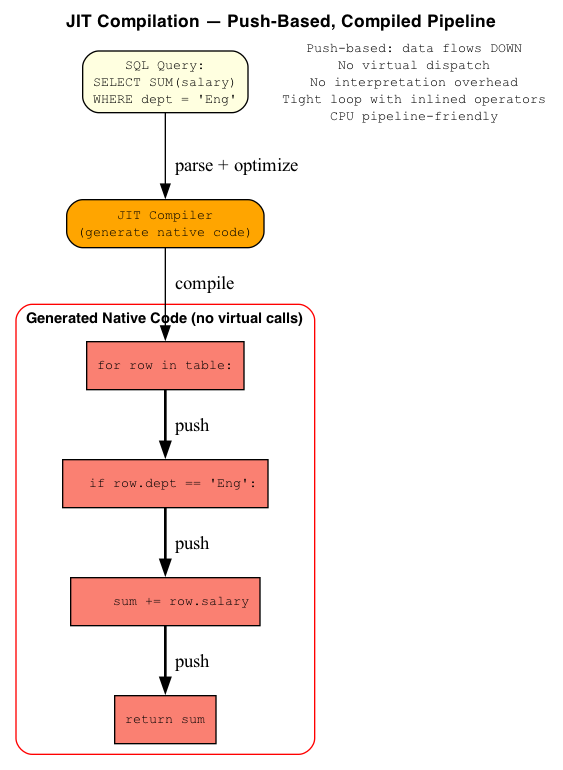

The JIT-compiled query is essentially:

  // Generated C code (compiled to machine code via LLVM)
  int64_t sum = 0;
  for (int i = 0; i < n_rows; i++) {
    if (dept[i] == ENGINEERING) {  // no virtual dispatch
      sum += salary[i];            // stays in register
    }
  }
  return sum;

→ No operator boundaries. No function calls. No materialization.
→ The compiler can optimize this like any C loop: unroll, vectorize, pipeline.


In [9]:
path = render_jit_model(
    query="SELECT SUM(salary)\nWHERE dept = 'Eng'",
    pipeline_stages=[
        "for row in table:",
        "  if row.dept == 'Eng':",
        "    sum += row.salary",
        "return sum",
    ],
    filename="jit", output_dir=OUTPUT_DIR,
)
if path.endswith(".png"):
    display(Image(filename=path))

print("The JIT-compiled query is essentially:")
print()
print("  // Generated C code (compiled to machine code via LLVM)")
print("  int64_t sum = 0;")
print("  for (int i = 0; i < n_rows; i++) {")
print("    if (dept[i] == ENGINEERING) {  // no virtual dispatch")
print("      sum += salary[i];            // stays in register")
print("    }")
print("  }")
print("  return sum;")
print()
print("→ No operator boundaries. No function calls. No materialization.")
print("→ The compiler can optimize this like any C loop: unroll, vectorize, pipeline.")

In [10]:
# Simulate JIT-compiled execution (hand-written tight loop)

# This is what JIT-compiled code looks like after compilation
start = time.time()
jit_sum = 0
jit_count = 0
sal = data["salary"]
dep = data["department"]
target = "Engineering"
for i in range(N):
    if dep[i] == target:
        jit_sum += sal[i]
        jit_count += 1
jit_time = time.time() - start

print(f"Result: SUM={jit_sum:,}, COUNT={jit_count:,}")
print(f"\nExecution model comparison ({N:,} rows):")
print(f"  Iterator (tuple-at-a-time):     {iterator_time:.3f}s")
print(f"  Batched (Python, concept only): {vec_time:.3f}s   ← shows batching reduces calls")
print(f"  Fused loop (JIT-style):         {jit_time:.3f}s   ← shows fusion eliminates operator boundaries")
print(f"  Vectorized+SIMD (NumPy):        {numpy_time:.3f}s   ← shows what real vectorized engines achieve")
print(f"\n→ Batched Python shows the CONCEPT of vectorized (fewer function calls).")
print(f"→ NumPy shows the REALITY of vectorized (SIMD on contiguous arrays).")
print(f"→ JIT would combine fusion (no operator boundaries) WITH SIMD — best of both.")
print(f"→ In production C++ engines, vectorized and JIT both approach the SIMD ceiling.")

Result: SUM=25,027,727,296, COUNT=200,387

Execution model comparison (1,000,000 rows):
  Iterator (tuple-at-a-time):     0.255s
  Batched (Python, concept only): 0.115s   ← shows batching reduces calls
  Fused loop (JIT-style):         0.066s   ← shows fusion eliminates operator boundaries
  Vectorized+SIMD (NumPy):        0.005s   ← shows what real vectorized engines achieve

→ Batched Python shows the CONCEPT of vectorized (fewer function calls).
→ NumPy shows the REALITY of vectorized (SIMD on contiguous arrays).
→ JIT would combine fusion (no operator boundaries) WITH SIMD — best of both.
→ In production C++ engines, vectorized and JIT both approach the SIMD ceiling.


---
## Part 4: Side-by-Side Comparison

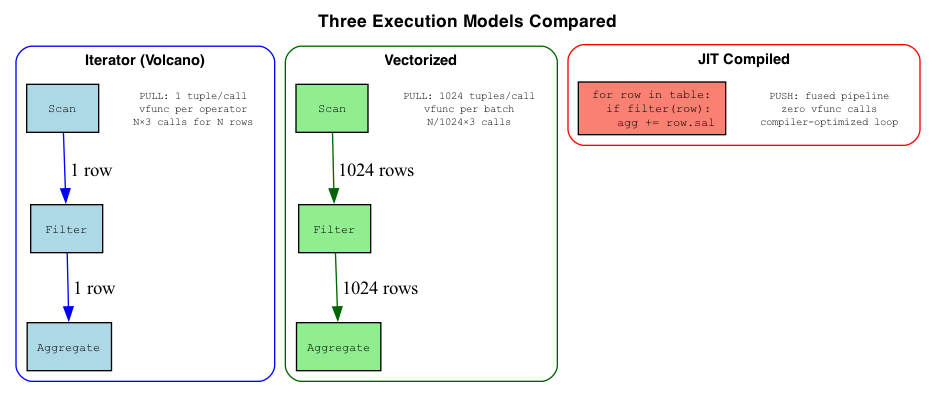

In [11]:
path = render_three_models_comparison(filename="comparison", output_dir=OUTPUT_DIR)
if path.endswith(".png"):
    display(Image(filename=path))

In [12]:
# Benchmark across data sizes
sizes = [100_000, 500_000, 1_000_000, 5_000_000]
iter_times = []
vec_times = []
jit_times = []
np_times = []

for n in sizes:
    random.seed(42)
    d = {
        "department": [random.choice(departments) for _ in range(n)],
        "salary": [random.randint(50000, 200000) for _ in range(n)],
    }
    
    # Iterator
    scan = ScanOperator(d)
    filt = FilterOperator(scan, "department", "Engineering")
    agg = AggregateOperator(filt, "salary")
    start = time.time()
    agg.next()
    iter_times.append(time.time() - start)
    
    # Batched (Python vectorized concept)
    scan = VecScan(d)
    filt = VecFilter(scan, "department", "Engineering")
    agg = VecAggregate(filt, "salary")
    start = time.time()
    agg.next_batch()
    vec_times.append(time.time() - start)
    
    # JIT-style fused loop
    sal = d["salary"]
    dep = d["department"]
    start = time.time()
    s = 0
    for i in range(n):
        if dep[i] == "Engineering":
            s += sal[i]
    jit_times.append(time.time() - start)
    
    # Vectorized + SIMD (NumPy)
    sa = np.array(d["salary"])
    da = np.array(d["department"])
    start = time.time()
    sa[da == "Engineering"].sum()
    np_times.append(time.time() - start)

print(f"{'Rows':>10} {'Iterator':>10} {'Batched':>10} {'Fused':>10} {'Vec+SIMD':>10}")
print("-" * 54)
for i, n in enumerate(sizes):
    print(f"{n:>10,} {iter_times[i]:>8.3f}s {vec_times[i]:>8.3f}s "
          f"{jit_times[i]:>8.3f}s {np_times[i]:>8.3f}s")

      Rows   Iterator    Batched      Fused   Vec+SIMD
------------------------------------------------------
   100,000    0.022s    0.009s    0.005s    0.001s
   500,000    0.113s    0.047s    0.028s    0.003s
 1,000,000    0.229s    0.087s    0.057s    0.005s
 5,000,000    1.140s    0.436s    0.284s    0.029s


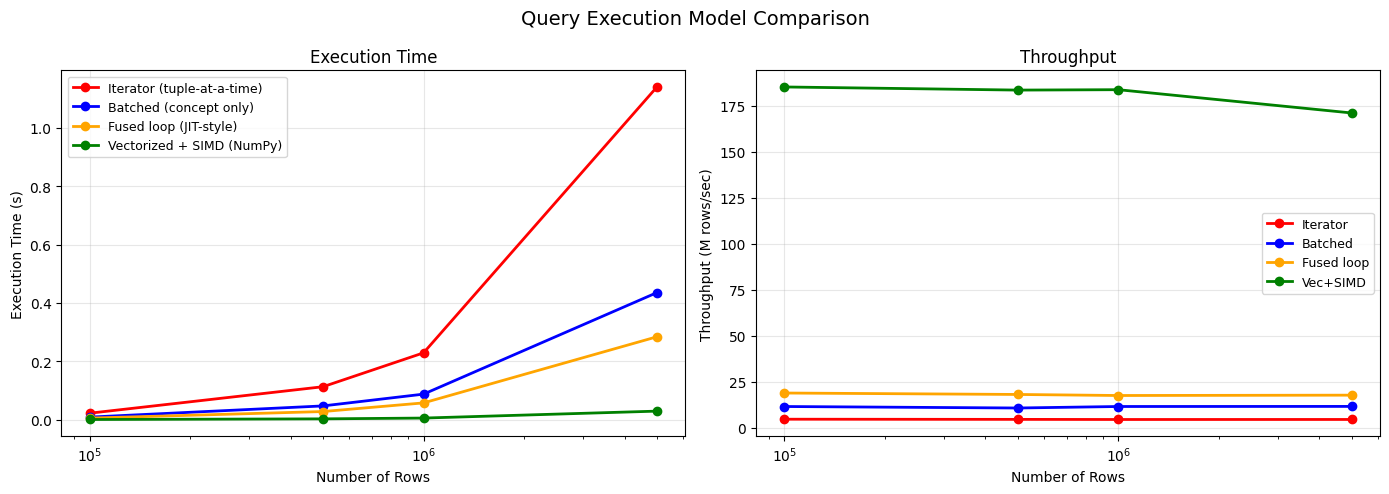

→ Iterator: slowest. Function call overhead per tuple.
→ Batched: fewer calls, but still Python — shows the concept, not the hardware benefit.
→ Fused loop: eliminates operator boundaries (JIT benefit).
→ Vec+SIMD: what real vectorized engines achieve. SIMD on contiguous arrays.
→ In production C++, JIT and vectorized both reach this SIMD ceiling.


In [13]:
# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Absolute times
ax1.plot(sizes, iter_times, 'o-', color='red', linewidth=2, label='Iterator (tuple-at-a-time)')
ax1.plot(sizes, vec_times, 'o-', color='blue', linewidth=2, label='Batched (concept only)')
ax1.plot(sizes, jit_times, 'o-', color='orange', linewidth=2, label='Fused loop (JIT-style)')
ax1.plot(sizes, np_times, 'o-', color='green', linewidth=2, label='Vectorized + SIMD (NumPy)')
ax1.set_xlabel('Number of Rows')
ax1.set_ylabel('Execution Time (s)')
ax1.set_title('Execution Time')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xscale('log')

# Throughput
ax2.plot(sizes, [n/t/1e6 for n, t in zip(sizes, iter_times)], 'o-', color='red', linewidth=2, label='Iterator')
ax2.plot(sizes, [n/t/1e6 for n, t in zip(sizes, vec_times)], 'o-', color='blue', linewidth=2, label='Batched')
ax2.plot(sizes, [n/t/1e6 for n, t in zip(sizes, jit_times)], 'o-', color='orange', linewidth=2, label='Fused loop')
ax2.plot(sizes, [n/t/1e6 for n, t in zip(sizes, np_times)], 'o-', color='green', linewidth=2, label='Vec+SIMD')
ax2.set_xlabel('Number of Rows')
ax2.set_ylabel('Throughput (M rows/sec)')
ax2.set_title('Throughput')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xscale('log')

plt.suptitle('Query Execution Model Comparison', fontsize=14)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/model_comparison.png', dpi=150)
plt.show()

print("→ Iterator: slowest. Function call overhead per tuple.")
print("→ Batched: fewer calls, but still Python — shows the concept, not the hardware benefit.")
print("→ Fused loop: eliminates operator boundaries (JIT benefit).")
print("→ Vec+SIMD: what real vectorized engines achieve. SIMD on contiguous arrays.")
print("→ In production C++, JIT and vectorized both reach this SIMD ceiling.")

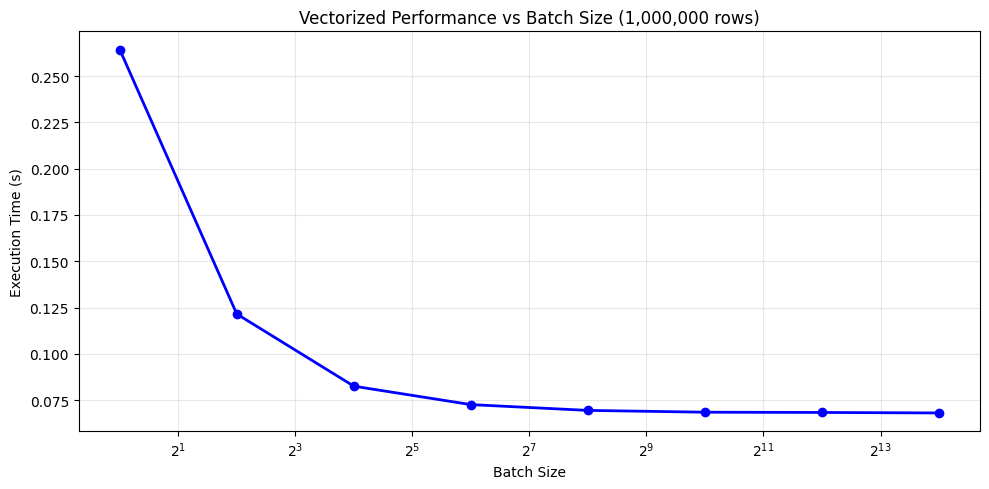

→ Batch size 1 = iterator model (worst). Performance improves rapidly up to ~1024.
→ Beyond ~1024, gains plateau — the batch exceeds L1 cache size.
→ Sweet spot: 1024-4096. This is why DuckDB/Velox use 1024-2048 as default.
→ Too large = cache thrashing. Too small = function call overhead.


In [14]:
# Batch size sensitivity: how does vector size affect performance?
batch_sizes_test = [1, 4, 16, 64, 256, 1024, 4096, 16384]
batch_times = []

for bs in batch_sizes_test:
    old_bs = BATCH_SIZE
    # Inline a quick test
    d = {"department": data["department"], "salary": data["salary"]}
    pos = 0
    total = 0
    n = len(d["salary"])
    start = time.time()
    while pos < n:
        end = min(pos + bs, n)
        for i in range(pos, end):
            if d["department"][i] == "Engineering":
                total += d["salary"][i]
        pos = end
    batch_times.append(time.time() - start)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(batch_sizes_test, batch_times, 'o-', color='blue', linewidth=2)
ax.set_xlabel('Batch Size')
ax.set_ylabel('Execution Time (s)')
ax.set_title(f'Vectorized Performance vs Batch Size ({N:,} rows)')
ax.set_xscale('log', base=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/batch_size.png', dpi=150)
plt.show()

print("→ Batch size 1 = iterator model (worst). Performance improves rapidly up to ~1024.")
print("→ Beyond ~1024, gains plateau — the batch exceeds L1 cache size.")
print("→ Sweet spot: 1024-4096. This is why DuckDB/Velox use 1024-2048 as default.")
print("→ Too large = cache thrashing. Too small = function call overhead.")

---
## Part 5: When to Use Which — Production Landscape

### The tradeoff space

| Dimension | Iterator | Vectorized | JIT |
|-----------|----------|-----------|-----|
| **Implementation complexity** | Simple | Medium | High (LLVM / codegen infra) |
| **Startup latency** | Zero | Zero | Compilation cost (amortized over execution) |
| **Throughput** | Baseline | High | Highest |
| **Extensibility** | High (plug in any operator) | Medium | Medium (operators must be codegen-aware) |

### What real systems use

| System | Model | Notes |
|--------|-------|-------|
| PostgreSQL | Iterator | Simplicity, extensibility, decades of operators |
| SQLite | Iterator | Bytecode VM (similar to iterator, slightly faster) |
| DuckDB | Vectorized | Analytical workloads, SIMD-optimized, no compile latency |
| Snowflake | Vectorized | Cloud analytics, predictable performance |
| ClickHouse | Vectorized | High-throughput analytics |
| Velox (Meta) | Vectorized | General-purpose engine for Presto/Spark |
| Spark (Tungsten) | JIT (Whole-Stage CodeGen) | Fuses operators into native code, huge wins on long-running queries |
| HyPer/Umbra | JIT (LLVM) | Pioneered query compilation; proven in production at Tableau/Salesforce |
| DataFusion | Vectorized + JIT | Hybrid: vectorized by default, JIT for hot paths |

### Each model has its sweet spot

**Iterator**: unmatched simplicity and extensibility. When your query engine needs to support
hundreds of operator types and user-defined functions, the iterator model's composability wins.
PostgreSQL has thrived on this for decades.

**Vectorized**: excellent throughput with zero startup cost. Ideal when queries are diverse,
latency-sensitive, and the engine must handle both short lookups and long scans.
The dominant choice for modern analytical engines (DuckDB, Snowflake, ClickHouse).

**JIT compilation**: highest possible throughput by eliminating ALL interpretation overhead.
The compilation cost is amortized over query execution — for long-running analytical queries,
this cost becomes negligible. Systems like HyPer/Umbra and Spark Tungsten have demonstrated
that JIT compilation can push query throughput to the hardware limit. When the workload
is compute-heavy and queries run long enough, JIT is the clear winner.

Many modern systems **combine** approaches: vectorized execution as the fast path,
with JIT compilation applied selectively to hot pipelines. This mirrors how JVMs and V8
work — interpret first, compile hot paths.

### The mental model

```
Iterator:    "Interpret the query plan, one tuple at a time"
             Simple. Composable. Universal.

Vectorized:  "Interpret the query plan, one BATCH at a time"
             Same architecture as iterator, but hardware-friendly.
             The MonetDB/X100 insight: amortize overhead across batches.

JIT:         "Compile the query plan into native code, then run it"
             Eliminate ALL interpretation overhead.
             The HyPer insight: queries are programs — compile them.
```

In [15]:
import glob
print("Lab complete! Output files:")
total = 0
for root, dirs, files in os.walk(OUTPUT_DIR):
    for f in files:
        fpath = os.path.join(root, f)
        size = os.path.getsize(fpath)
        total += size
file_count = sum(len(files) for _, _, files in os.walk(OUTPUT_DIR))
print(f"  {file_count} files, {total:,} bytes total")
print(f"  All contained in {OUTPUT_DIR}/")

Lab complete! Output files:
  12 files, 358,418 bytes total
  All contained in _output/
